##### Task Description: Fe Deficiency detection based on the different hyperspectral spectral imaging (i.e., measuring leaf reflectance at different wavelengths in the range of 400 to 1000 nm). Introducing index for -Fe, by applying the SHAP method in the TRAIN Phase of 1) Logistic Regression 2) Random Forest that have been trained on all Trimmed features (169) and extracting 9 important features in each, and finally, using these features in the Logistic Regression's formula.
- <font color=red> Delete 18 spectra from the beginning and 17 from the end of all Train and Test sets as the sensitivity of the measuring device in these parts is low ---> 169 features/columns are left (from X449.35 up to X951.17) </font>
- Train size (without feature selection) = Original dataset (144, 169), and (180, 169) if we add 36 samples of Michele to the original dataset
- Test size (without feature selection) = (86, 169) if we merge Anna 1, Anna 2, and Marco1, and (121, 169) if we merge Anna 1, Anna 2, Marco1, and 35 samples of Michele
- <font color=red> The SHAP plots are for class 1 which is "Fe deficiency" here </font>

#### Methods
- Linear Logistic Regression 
- Random Forest


In [15]:
# Essential Libraries
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer,  precision_score,  recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
# Initialize JavaScript for SHAP visualizations
shap.initjs()
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
# New, for ShapG
# import shapG and necessary libraries
import networkx as nx
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import pearsonr,kendalltau,spearmanr
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('.'), '..')))
import shapG.shapley as shapley
import shapG.plot as shapGplot
from shapG.utils import corr_generator, create_minimal_edge_graph, matrix_generator, kl, kl_mi_matrix
import lightgbm as lgb
# from sklearn.metrics import r2_score
from sklearn.metrics import f1_score

In [53]:
# # This cell is for selecting (randomly) 36 sample of eddited version of "Michele" into the original dataset, 9 sample per each plant

# # Load both text files
# df_first = pd.read_csv("Michele_column_names_editted.txt", delimiter="\t")  
# df_second = pd.read_csv("Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt", delimiter="\t")

# # Ensure 'Species' column exists in df_first
# if 'Species' not in df_first.columns:
#     raise ValueError("Column 'Species' not found in first file!")

# # Randomly sample 9 rows per plant type (keeping entire rows) ---> 36, in total
# samples_to_add = df_first.groupby("Species", group_keys=False).apply(lambda x: x.sample(n=9, random_state=42))

# # Reset index to preserve row structure
# samples_to_add = samples_to_add.reset_index(drop=True)

# # Append the selected rows to df_second WITHOUT considering column names
# df_updated = pd.concat([df_second, samples_to_add], axis=0, ignore_index=True)

# # Save the updated file
# df_updated.to_csv("Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe_add36_randomly.txt", sep="\t", index=False)
# print("Successfully added 9 full rows per plant type without considering column names!")

# # Remove ONLY the selected 36 rows from df_first (using exact match)
# df_remaining = df_first[~df_first.apply(tuple, axis=1).isin(samples_to_add.apply(tuple, axis=1))]  
# # Save the cleaned dataset (without the 18 removed samples)
# df_remaining.to_csv("Michele_test3.txt", sep="\t", index=False)



Successfully added 9 full rows per plant type without considering column names!


C:\Users\hassa\AppData\Local\Temp\ipykernel_2840\798564287.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples_to_add = df_first.groupby("Species", group_keys=False).apply(lambda x: x.sample(n=9, random_state=42))


In [24]:
# # read "Anna3_specim_16_May.txt" and merge it with the big test set "Merged_Anna1_Anna2_Marco1_Random_Michele_fornew_trainSet"
# # Load both text files
# df_anna_specim = pd.read_csv("Anna3_specim_16_May.txt", delimiter="\t")  
# df_big_test = pd.read_csv("Merged_Anna1_Anna2_Marco1_Random_Michele_fornew_trainSet.txt", delimiter="\t")

# # Drop the first column (assuming it's the first column based on index 0)
# df_anna_specim.drop(df_anna_specim.columns[0], axis=1, inplace=True)
# # Add a new column titled "Specie" with the value "Barley" for all rows
# df_anna_specim.insert(0, "Specie", "Barley")
# df_anna_specim.insert(2, "Replicates", "Undefined")
# df_anna_specim.rename(columns={"treatment": "Fe_deficiency "}, inplace=True)

# print(df_anna_specim.columns)  # Check if "column names" have changed correctly
# # Verify the changes
# print(df_anna_specim.head())
# print(df_big_test.head())

# # merge the 2 dataframes
# Anna_bigTest = pd.concat([df_big_test,df_anna_specim])

# # Verify the shape of the final data
# print(df_anna_specim.shape)
# print(df_big_test.shape)
# print("Anna_bigTest shape:", Anna_bigTest.shape)  

# # Find column differences between the two DataFrames
# diff_columns = set(df_anna_specim.columns) ^ set(df_big_test.columns)
# print("Columns that do not match:", diff_columns)

# # # Save the combined data to a new tab-delimited .txt file
# Anna_bigTest.to_csv('Merged_Anna1_Anna2_Marco1_RandomMichele_Anna3Specim.txt', sep='\t', index=False, header=df_big_test.columns)

#### Load and Preprocess Datasets
- Drop the 'Leaf' column as it provides no classification information (it has the same value 'YL' for all rows in "Original dataset")
- Encode the 'Thesis' column (the ground-truth label)
- Separate the dataset into features and labels
- check class imbalance in the whole dataset
- Check for missing values in the entire DataFrame (There was none)
- Feature selection - Get feature importances using Random Forest
- Scale the feature values (Columns here) using Z-Score method

##### <font color=red> Important Notes </font>
- For executing the "Trimmed" version, uncomment all reduced variables (X_reduced, feature_names_reduced, X_scaled after reducing dimensions). Comment them if you wish to consider "All Wavelengths"
- Watch the consistency between encoded labels of the all datasets to be consistent
- Execute the Train&Test sets that are in the same Phases


    X449.35   X452.25   X455.16   X458.06   X460.96   X463.87   X466.77  \
0  0.042277  0.042008  0.043067  0.044406  0.045149  0.045336  0.045126   
1  0.044766  0.044694  0.045867  0.047107  0.047637  0.047397  0.047142   
2  0.044423  0.044098  0.044917  0.046108  0.046765  0.046932  0.046728   
3  0.042280  0.042262  0.043355  0.044542  0.044986  0.044762  0.044539   
4  0.040464  0.040462  0.041544  0.042791  0.043524  0.043492  0.043271   

    X469.68   X472.59   X475.50  ...   X923.55   X926.61   X929.68   X932.74  \
0  0.044939  0.044777  0.044812  ...  0.679419  0.678313  0.677439  0.674031   
1  0.046870  0.046584  0.046517  ...  0.661461  0.660706  0.660174  0.657171   
2  0.046639  0.046462  0.046473  ...  0.684159  0.683024  0.682663  0.679283   
3  0.044244  0.044042  0.043820  ...  0.659238  0.659078  0.658764  0.655813   
4  0.042954  0.042850  0.042745  ...  0.650903  0.649977  0.648879  0.645934   

    X935.81   X938.88   X941.95   X945.02   X948.10   X951.17  
0  0

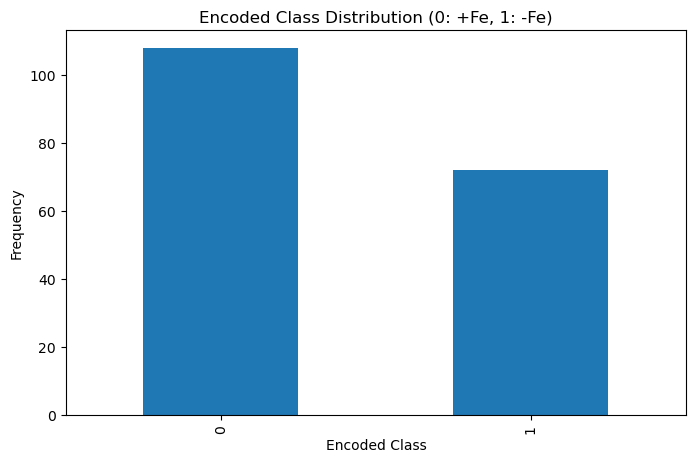

Encoded Class Distribution:
0    108
1     72
Name: count, dtype: int64


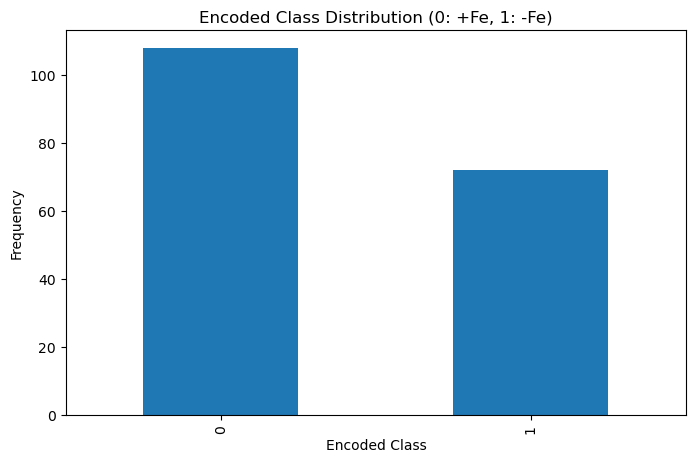

Columns with missing values: []

Number of features with 0.0 importance: 70


(180, 169)

In [3]:
# Step 1: Load the Train dataset

# *********** Phase 1's train set ************
# Load the "original dataset"
# data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt', delimiter='\t')
# *********** Phase 2's train set ************
# Load the "original dataset + 36_Randomly_chosen_Michele_samples"
data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe_add36_randomly.txt', delimiter='\t')
# Step 2: Preprocess the data
# Drop the 'leaf' column
data = data.drop(columns=['Leaf'])

# Separate the dataset into features and labels
# Include all Wavelengths
# X = data.iloc[:, 3:]
# Remove noisy beginning and ending wavelengths (i.e., include only trimmed version)
X = data.iloc[:, 21:190]

#### Only Use the FEATURES that the SHAP method detected as important WHEN All TRIMMED WAVELENGTHS WERE CONSIDERED ####
## select only important Wavelengths introduced by SHAP, comment "reduced-related" codes, and also "X = data.iloc[]" above  for these states
    ### Phase 1's wavelenghs ###
# For Merged Dataset, All Features, LogisticRegression
# desired_columns = ['X714.55', 'X717.54', 'X711.56', 'X720.54', 'X708.57', 'X723.53', 'X726.53', 'X729.53', 'X819.95']
# For Merged Dataset, Some Features, Logistic Regression ---> not useful
# desired_columns = ['X714.55', 'X753.55', 'X717.54', 'X756.56', 'X711.56', 'X708.57', 'X705.57', 'X720.54', 'X807.84']
# For Merged Dataset, All Features, Random Forest
# desired_columns = ['X702.58', 'X714.55', 'X705.57', 'X708.57', 'X711.56', 'X717.54', 'X563.24', 'X542.68', 'X720.54']
# For Merged Dataset, Some Features, Random Forest ---> not useful
# desired_columns = ['X711.56', 'X717.54', 'X708.57', 'X539.75', 'X545.62', 'X702.58', 'X648.95', 'X554.43','X563.24']
    ### Phase 2's wavelenghs ### --> using a new train set that has been augmented with 36 RANDOMLY-added features of Michele###
# LogisticRegression
# desired_columns =['X723.53','X720.54','X726.53','X501.72','X504.64', 'X929.68', 'X507.56', 'X498.80', 'X449.35']
# Random Forest
# desired_columns = ['X702.58', 'X699.60', 'X714.55', 'X705.57', 'X525.10', 'X708.57','X696.61', 'X711.56','X569.12']

#### New Ablation Test ----> Use Phase 2's SHAP wavelenghs/features ###
# LogisticRegression, Use Top 4 SHAP features
# desired_columns=['X723.53', 'X720.54', 'X726.53', 'X501.72']
# RandomForest, Use Top 4 SHAP features
# desired_columns=['X702.58', 'X699.60', 'X714.55', 'X705.57']
# LogisticRegression, Use Top unique SHAP features
# desired_columns=['X723.53', 'X501.72', 'X929.68', 'X498.80'] 
# RandomForest, Use Top unique SHAP features
# desired_columns=['X702.58', 'X699.60', 'X525.10']

# uncomment the following line if you choose SHAP features in "desired_columns" and not "all or trimmed" ones.
# X = data[desired_columns]

print(X.head())

y = data['Thesis']
# Encode the 'Thesis' column
# le = LabelEncoder()
# y = le.fit_transform(y)
# Encode 'Thesis' column based on "+Fe" and "-Fe"
y = data['Thesis'].apply(lambda label: 0 if '+Fe' in label else 1)
# Confirm the encoding
print(y.value_counts())  # Displays the distribution of 0s and 1s
plt.figure(figsize=(8, 5))
y.value_counts().plot(kind='bar')
plt.title('Encoded Class Distribution (0: +Fe, 1: -Fe)')
plt.xlabel('Encoded Class')
plt.ylabel('Frequency')
plt.show()

feature_names = X.columns.tolist()

# Step 4: Encode the target variable
# Map "+Fe" to 0 and "-Fe" to 1
data['Thesis'] = data['Thesis'].apply(lambda label: 0 if '+Fe' in label else 1)
# Initialize and fit LabelEncoder (optional for compatibility)
le = LabelEncoder()
y = le.fit_transform(data['Thesis'])
# Step 5: Show the encoded class distribution
print("Encoded Class Distribution:")
print(pd.Series(y).value_counts())
# Plot the class distribution
plt.figure(figsize=(8, 5))
pd.Series(y).value_counts().plot(kind='bar')
plt.title('Encoded Class Distribution (0: +Fe, 1: -Fe)')
plt.xlabel('Encoded Class')
plt.ylabel('Frequency')
plt.show()

# Check for missing values --> none
print(f"Columns with missing values: {data.columns[data.isnull().any()].tolist()}")

# Feature selection ------------------>??
rf = RandomForestClassifier(n_estimators=15, random_state=42)
rf.fit(X, y)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
# Count the number of features with 0.0 importance and print their names
zero_importance_features = feature_importances[feature_importances == 0.0].index.tolist()
print(f"\nNumber of features with 0.0 importance: {len(zero_importance_features)}")
# print("Features with 0.0 importance:", zero_importance_features)
# print("\nFeature Importances:")
# print(feature_importances.sort_values(ascending=False))
# Remove zero importance features from X
# X_reduced = X.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced.columns.tolist()
# print("\nX_reduced.shape is ", X_reduced.shape)
# print("\nX_reduced names.shape is ", len(feature_names_reduced))
# print(feature_names_reduced)
#Scale the feature/columns values
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_reduced)
X_scaled = scaler.fit_transform(X)
X_scaled.shape

### Test Set Preparation
1) Merge Anna1+Anna2+Marco1 ("Merged_Anna1_Anna2_Marco_as_test.txt")
3) Merge Anna1+Anna2+Marco1+Michele-36 Randomly chosen samples ("Michele_test3.txt")

In [56]:
# # this cell is used to merge Anna1, Anna2, Marco1, and remaining samples of Michele
# # Read the first file normally (to include its header if needed)
# data1 = pd.read_csv('Exp_I_Anna_Fe_Tomato.txt', sep='\t', header=None)  # Shape (18, 207)

# # Read the second and third files while skipping their headers
# data2 = pd.read_csv('Exp_II_Anna_Fe_Tomato.txt', sep='\t', header=None, skiprows=1)  # Skip the header row
# data3 = pd.read_csv('Exp_Marco_tesista_Fe_Lupino.txt', sep='\t', header=None, skiprows=1)  # Skip the header row
# # add this when the "Random state" is needed/ phase 2
# data4 = pd.read_csv('Michele_test3.txt', sep='\t', header=None, skiprows=1)

# # Replace values in the new first column (previously index 1)
# data4[1] = data4[1].replace({'Zm': 'Maize', 'Sl': 'Tomato', 'Hv':'Barley', 'Cs': 'Cucumber'})

# # Drop the original first column
# data4 = data4.drop(columns=[0])

# # Reset column names to ensure correct alignment
# data4.columns = range(data4.shape[1])

# # Reset index to prevent misalignment
# data4.reset_index(drop=True, inplace=True)

# # Check columns in data4
# print(data4.columns)  # This will list all column indices (0 to 207)
# # Check for rows with extra values
# # extra_column_data = data4.iloc[:, 207]  # Access the extra column (index 207)
# # print(extra_column_data)
# # Drop column 207 if it's entirely NaN
# # data4 = data4.dropna(axis=1, how='all')  # Removes columns with all NaN values
# # Check the shape to confirm
# print(data4.shape)


# final_data = pd.concat([data1, data2, data3, data4])

# # Verify the shape of the final data
# print(data1.shape)
# print(data2.shape)
# print(data3.shape)
# print(data4.shape)
# print("Final shape:", final_data.shape)  # Should print (86, 207)

# # Save the combined data to a new tab-delimited .txt file
# # add this when the "Random state" is needed/ phase 2
# final_data.to_csv('Merged_Anna1_Anna2_Marco1_Random_Michele_fornew_trainSet.txt', sep='\t', index=False, header=False)

   Specie Fe_deficiency  Replicates    397.32     400.2    403.09    405.97  \
0  Tomato          +N+Fe          1  0.138507  0.120903  0.107281  0.099468   
1  Tomato          +N+Fe          2  0.153739  0.134105  0.118036  0.108338   
2  Tomato          +N+Fe          3  0.156368  0.137271  0.118881  0.109219   
3  Tomato          +N+Fe          4  0.171283  0.148006  0.130491  0.119070   
4  Tomato          +N+Fe          5  0.336768  0.289659  0.251961  0.226502   

     408.85    411.74    414.63  ...    975.79    978.88    981.96    985.05  \
0  0.092691  0.087703  0.083688  ...  0.767504  0.762315  0.766776  0.764412   
1  0.099845  0.094819  0.090948  ...  0.764722  0.759554  0.764497  0.761272   
2  0.100638  0.095236  0.091980  ...  0.729035  0.726149  0.730765  0.728527   
3  0.110157  0.103453  0.099363  ...  0.777392  0.773757  0.778058  0.777762   
4  0.206728  0.190581  0.177860  ...  0.735353  0.732939  0.739019  0.739125   

     988.13    991.22    994.31     997.4   

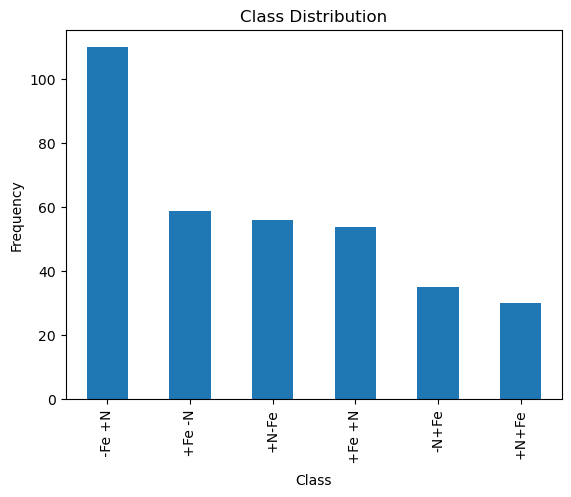

Custom Label Encoding Mapping:
+Fe -> 0, -Fe -> 1
Encoded Labels Preview:
0    0
1    0
2    0
3    0
4    0
Name: Thesis, dtype: int64
Columns with missing values: []
(344, 169)
New Encoded Class Distribution in Test Set:
Thesis
0    178
1    166
Name: count, dtype: int64


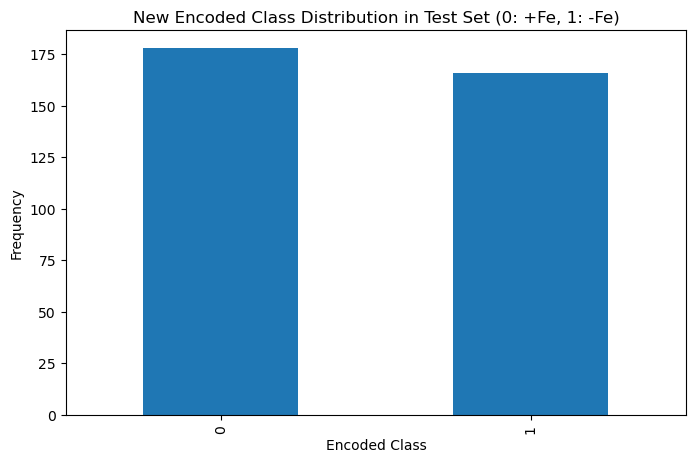

In [7]:
# Step 1: Load the test dataset
# *********** Phase 1's test set ************
# old test (a), Michele's samples are not included
# test_df = pd.read_csv('Merged_Anna1_Anna2_Marco1_as_test.txt', delimiter='\t')
# old test (b), Load the "Anna1 + Anna2 + Marco1 + 71_young_leaf_samples_of_Michele"
# test_df = pd.read_csv('Merged_Anna1_Anna2_Marco1_Michele_as_test.txt', delimiter='\t')
# *********** Phase 2's test set ************
# # Load the "Anna1 + Anna2 + Marco1 + 35_Remaining_samples_of_Michele"
# test_df = pd.read_csv('Merged_Anna1_Anna2_Marco1_Random_Michele_fornew_trainSet.txt', delimiter='\t')
# # Load the "Anna1 + Anna2 + Marco1 + 35_Remaining_samples_of_Michele + Anna3_specim_16_May"
test_df = pd.read_csv('Merged_Anna1_Anna2_Marco1_RandomMichele_Anna3Specim.txt', delimiter='\t')

# Phase3, test index on each pla
nt type of the test set individually. Marco1 has Lupine, Anna3 has Barely
# read only Marco1's rows, the Lupine crop
# test_df = pd.read_csv('Merged_Anna1_Anna2_Marco1_RandomMichele_Anna3Specim.txt', delimiter='\t', skiprows=range(1, 79), nrows=8)
# read only Anna3's rows, the Barely crop
# test_df = pd.read_csv('Merged_Anna1_Anna2_Marco1_RandomMichele_Anna3Specim.txt', delimiter='\t').iloc[list(range(103, 112)) + list(range(121, len(pd.read_csv('Merged_Anna1_Anna2_Marco1_RandomMichele_Anna3Specim.txt', delimiter='\t'))))]
# read Anna1+Anna2+Michele's rows, the Tomato crop
# test_df = pd.read_csv('Merged_Anna1_Anna2_Marco1_RandomMichele_Anna3Specim.txt', delimiter='\t').iloc[list(range(0,78)) + list(range(94, 103))]
# read only Michele's "Cucumber" rows
# test_df = pd.read_csv('Merged_Anna1_Anna2_Marco1_RandomMichele_Anna3Specim.txt', delimiter='\t', skiprows=range(1, 87), nrows=8)
# read only Michele's "Maize" rows
# test_df = pd.read_csv('Merged_Anna1_Anna2_Marco1_RandomMichele_Anna3Specim.txt', delimiter='\t', skiprows=range(1, 113), nrows=9)


# check if correct rows are read
print (test_df.head())
print(test_df["Specie"].to_string())

# Step 2: Preprocess the data
# Rename the column "Fe deficiency" to "Thesis"
test_df.rename(columns={'Fe_deficiency ': 'Thesis'}, inplace=True)
print(test_df.head())

# # Separate the dataset into features and labels
# Include all Wavelengths
# X_te = test_df.iloc[:, 3:]
# Remove noisy beginning and ending wavelengths (i.e., trimmed version)
X_te = test_df.iloc[:, 21:190]

#### SHAP FEATURES EXTRACTED WHEN ALL WAVELENGTHS WERE CONSIDERED ####
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Merged Dataset, All Features, Logistic Regression
# desired_columns1 = ['714.55', '717.54', '711.56', '985.05', '997.4', '720.54', '994.31', '708.57', '723.53']
# For Merged Dataset, Some Features, Logistic Regression
# desired_columns1 = ['714.55', '711.56', '708.57', '720.54', '705.57', '723.53', '702.58', '750.54', '726.53']
# For Merged Dataset, All Features, Random Forest
# desired_columns1 = ['705.57', '702.58', '708.57', '711.56', '714.55', '569.12', '542.68', '699.6', '560.3']
# For Merged Dataset, Some Features, Random Forest
# desired_columns1 = ['714.55', '702.58', '711.56', '708.57', '705.57', '566.18', '699.6', '589.75', '580.9']

#### Only Use the FEATURES that the SHAP method detected as important WHEN All TRIMMED WAVELENGTHS WERE CONSIDERED ####
## select only important Wavelengths introduced by SHAP, comment "reduced-related" codes, and also "X_te = test_df.iloc[]" above  for these states

#### SHAP FEATURES EXTRACTED WHEN TRIMMED WAVELENGTHS WERE CONSIDERED ####
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
    ### Phase 1's wavelenghs ###
# desired_columns1 = ['714.55', '717.54', '711.56', '720.54', '708.57', '723.53', '726.53', '729.53', '819.95']
# For Merged Dataset, Some Features, Logistic Regression ---> not useful
# desired_columns1 = ['714.55', '753.55', '717.54', '756.56', '711.56', '708.57', '705.57', '720.54', '807.84']
#For Merged Dataset, All Features, Random Forest
# desired_columns1 = ['702.58', '714.55', '705.57', '708.57', '711.56', '717.54', '563.24', '542.68', '720.54']
# For Merged Dataset, Some Features, Random Forest ---> not useful
# desired_columns = ['711.56', '717.54', '708.57', '539.75', '545.62', '702.58', '648.95', '554.43','563.24']
    ### Phase 2's wavelenghs ### --> using a new train set that has been augmented with 36 RANDOMLY-added features ###
# LogisticRegression
# desired_columns1 =['723.53','720.54','726.53','501.72','504.64', '929.68', '507.56', '498.8', '449.35']
# Random Forest
# desired_columns1 = ['702.58', '699.6', '714.55', '705.57', '525.1', '708.57','696.61', '711.56','569.12']

#### New Ablation Test ----> Use Phase 2's SHAP wavelenghs/features ###
# LogisticRegression, Use Top 4
# desired_columns1=['723.53', '720.54', '726.53', '501.72']
# RandomForest, Use Top 4
# desired_columns1=['702.58', '699.6', '714.55', '705.57']
# LogisticRegression, Use Top unique features
# desired_columns1=['723.53', '501.72', '929.68', '498.8'] 
# RandomForest, Use Top unique features
# desired_columns1=['702.58', '699.6', '525.1']

# uncomment the following line if you choose "desired_columns1"
# X_te= test_df[desired_columns1]
print(X_te.head())
# Ensure that X_te has the correct number of columns as X
X_te.columns = X.columns  # Update the column names to match those in X (original dataset)
# Verify the change
print(X_te.head())
y_te = test_df['Thesis']

# Check the distribution/imbalance of the target variable
class_distribution = test_df['Thesis'].value_counts()
# Print the class distribution
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

# # Encode the 'Thesis' column
le_te = LabelEncoder()
# y_te = le_te.fit_transform(y_te)
# New way of Encoding the 'Thesis' column based on custom logic
y_te = test_df['Thesis'].apply(lambda x: 0 if '+Fe' in x else 1)

# Print custom mapping for verification
print("Custom Label Encoding Mapping:")
print("+Fe -> 0, -Fe -> 1")
print("Encoded Labels Preview:")
print(y_te.head())


# Check for missing values --> none
print(f"Columns with missing values: {test_df.columns[test_df.isnull().any()].tolist()}")

# Remove zero importance features from X_te
# X_reduced_te = X_te.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced_te.columns.tolist()
# print("\nX_reduced_te.shape is ", X_reduced_te.shape)
# print("\nX_reduced_te names.shape is ", len(feature_names_reduced))
# Scale the feature/columns values
scaler = StandardScaler()
# X_scaled_te = scaler.fit_transform(X_reduced_te)
X_scaled_te = scaler.fit_transform(X_te)
print(X_scaled_te.shape)


# Check the encoded distribution
encoded_distribution_train = y_te.value_counts()
# Print the distribution
print("New Encoded Class Distribution in Test Set:")
print(encoded_distribution_train)

# Visualize the encoded class distribution
plt.figure(figsize=(8, 5))
encoded_distribution_train.plot(kind='bar')
plt.title('New Encoded Class Distribution in Test Set (0: +Fe, 1: -Fe)')
plt.xlabel('Encoded Class')
plt.ylabel('Frequency')
plt.show()


#### Very important: Check if encoded labels are consistant in the train and test datasets

In [8]:
print("Label Encoding Mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

# print("Label Encoding Mapping:")
# for i, label in enumerate(le_te.classes_):
#     print(f"{label}: {i}")

# Systematic check for encoding using y_te
print("Label Encoding Mapping:")
for label in test_df['Thesis'].unique():
    encoded_value = y_te[test_df['Thesis'] == label].iloc[0]  # Find the corresponding encoded value from y_te
    print(f"{label}: {encoded_value}")

# # Display the original and encoded values in the Thesis column
# print("Original and Encoded Thesis Labels:")
# test_df_miki['Original_Thesis'] = pd.read_csv('Exp_4_Specie_Michele_Fe_and_N.txt', delimiter='\t')['Thesis']  # Reload original data for comparison
# print(test_df_miki[['Original_Thesis', 'Thesis']].drop_duplicates())

Label Encoding Mapping:
0: 0
1: 1
Label Encoding Mapping:
+N+Fe: 0
+N-Fe: 1
-N+Fe: 0
 +Fe +N: 0
 +Fe -N: 0
 -Fe +N: 1


#### <font color=red> New Split Mode ---> D</font>
#### <font color=red> We no longer use the same dataset for creating both train and test set (i.e. they are formed from separated datasets) </font>

In [9]:
X_train, y_train = X_scaled, y
X_test, y_test = X_scaled_te, y_te

# Confirm the shape of the train and test sets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (180, 169), y_train shape: (180,)
X_test shape: (344, 169), y_test shape: (344,)


#### Hyperparameter Tuning Using GridSearchCV , Model Training, and Evaluation
- Linear Logistic Regression </font>
- Randomforest

- <font color=red> Crossfold Validation is done in GridSearch (in Hyperparameter tuning) in each of the methods
</font>

#### <font color=green> Standard Logistic Regression </font>

Best parameters for Logistic Regression: {'C': 30, 'penalty': 'l2', 'solver': 'liblinear'}

Cross-Validation Scores from GridSearchCV:
     mean_test_score  std_test_score  \
0          0.827778        0.096864   
1          0.811111        0.110275   
2          0.833333        0.094608   
3          0.811111        0.115737   
4          0.794444        0.119928   
5          0.811111        0.115737   
6          0.811111        0.107439   
7          0.811111        0.107439   
8          0.811111        0.107439   
9          0.861111        0.115202   
10         0.866667        0.111665   
11         0.844444        0.111941   
12         0.872222        0.123728   
13         0.888889        0.112491   
14         0.850000        0.116003   

                                               params  
0     {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}  
1   {'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...  
2       {'C': 0.01, 'penalty': 'l2', 'solver': 'sag'}  
3      {'C': 0.

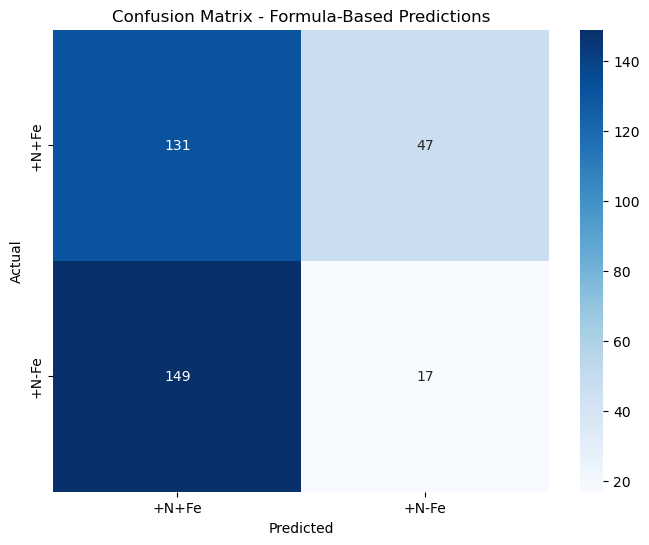


Standard Logistic Regression - Test Set Accuracy: 0.43023255813953487
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.74      0.57       178
           1       0.27      0.10      0.15       166

    accuracy                           0.43       344
   macro avg       0.37      0.42      0.36       344
weighted avg       0.37      0.43      0.37       344

Unique values in y_te: [0 1]
Unique values in y_pred: [0 1]


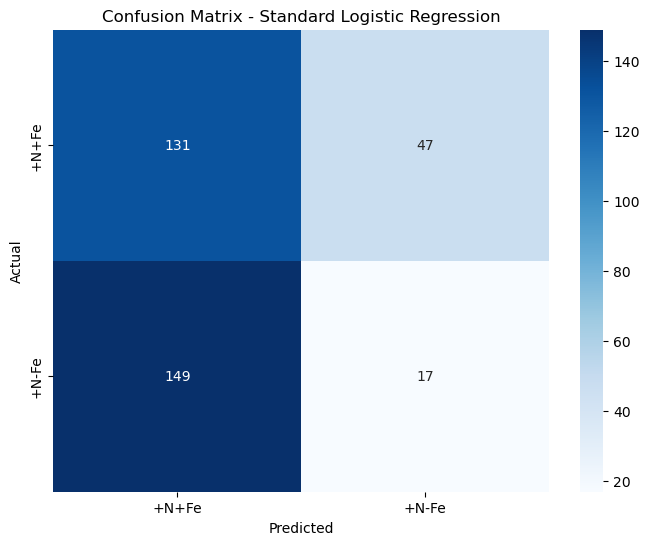

Linear Logistic Regression shap_values shape is (180, 169)


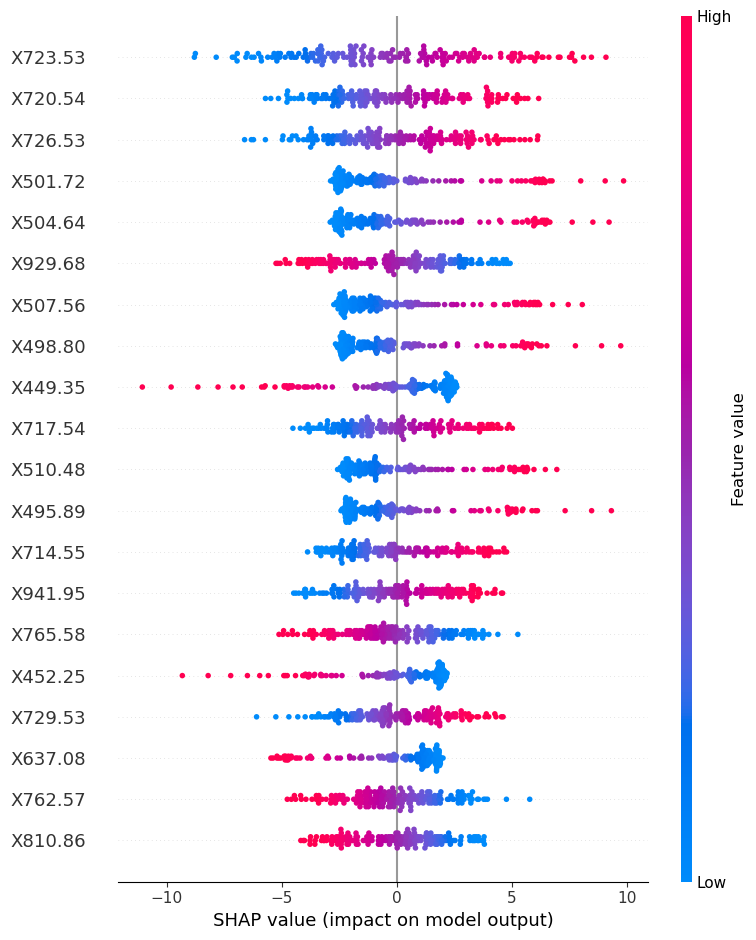

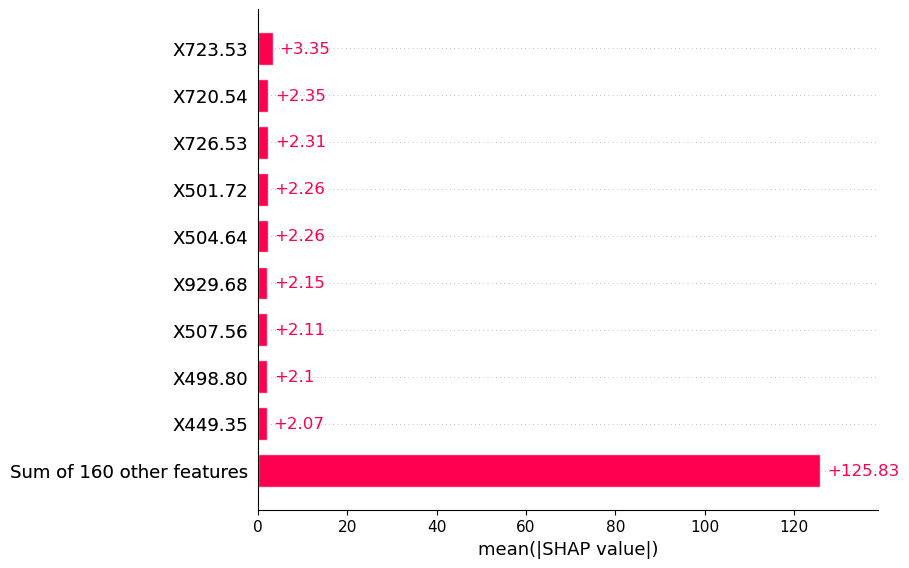

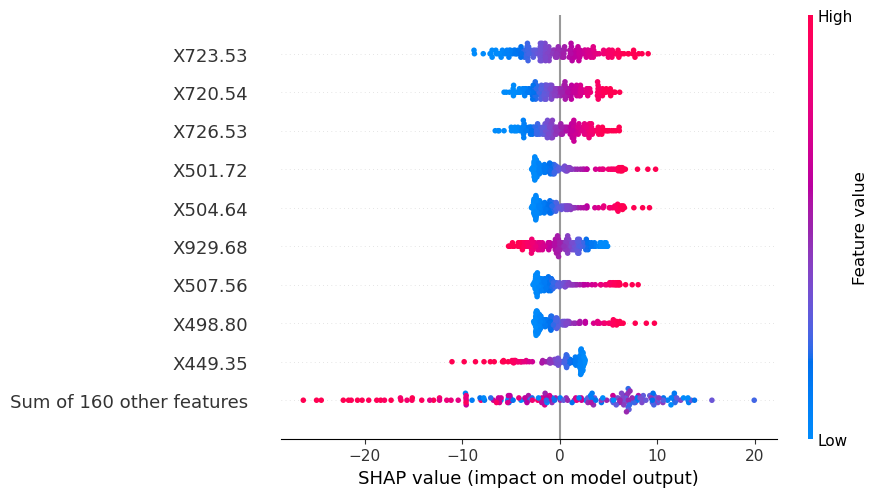

(180, 169)


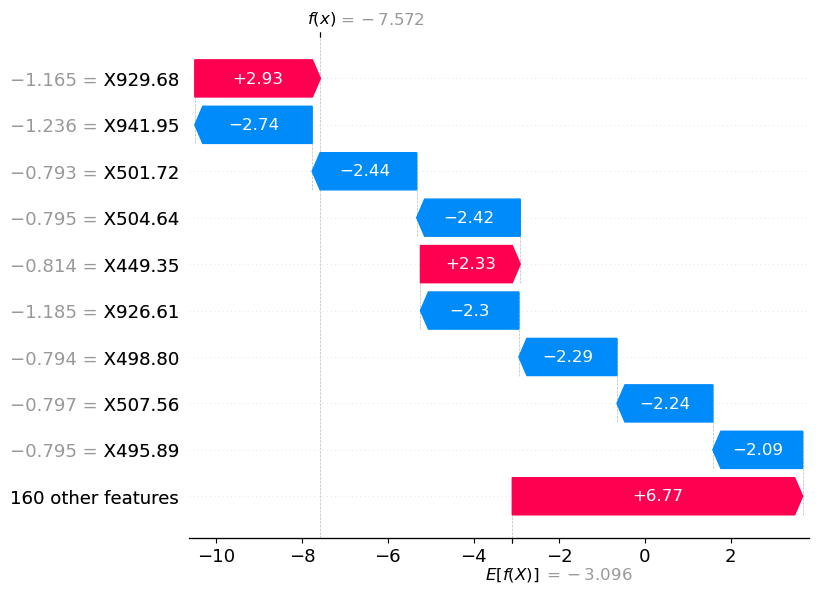

Model classes: [0 1]


In [10]:
### Hyperparameter Tuning and Cross-Validation for Standard Logistic Regression ###
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 30],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear', 'sag']
}
random_state= 42
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000, tol=1e-3,random_state=random_state), param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)
best_params_lr = grid_search_lr.best_params_
print("Best parameters for Logistic Regression:", best_params_lr)

# Print Cross-Validation Scores from GridSearchCV
cv_results = pd.DataFrame(grid_search_lr.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best logistic regression model
model = LogisticRegression(**best_params_lr, max_iter=5000, tol=1e-3, random_state=random_state)

# # Perform cross-validation
# cv_scores_lr = cross_val_score(model, X_train, y_train, cv=5)
# print("\nStandard Logistic Regression - Cross-Validation Scores:", cv_scores_lr)
# print("Mean Cross-Validation Score:", cv_scores_lr.mean())

# Train the model on the entire training set
model.fit(X_train, y_train)

# Extract coefficients and intercept
coefficients = model.coef_[0]  # For binary classification; adjust for multiclass
intercept = model.intercept_[0]  # For binary classification; adjust for multiclass
# Print coefficients and intercept with feature names
print("Intercept:", intercept)
print("Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
# Save the coefficients and intercept to a .txt file without rounding
output_file = "feature_coefficients_exact.txt"
with open(output_file, "w") as f:
    f.write(f"Intercept: {intercept}\n")
    f.write("Coefficients:\n")
    for feature, coef in zip(feature_names, coefficients):
        f.write(f"{feature}: {coef}\n")
print(f"Exact coefficients and intercept saved to {output_file}")
# Make predictions on the test set
y_pred = model.predict(X_scaled_te)
# Calculate predictions using the logistic regression formula
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Compute the linear combination (z)
z = intercept + np.dot(X_scaled_te, coefficients)  # Use the test set features
# Apply sigmoid to get probabilities
probabilities = sigmoid(z)
# Convert probabilities to binary predictions with a threshold of 0.5
predictions_formula = (probabilities >= 0.5).astype(int)
# Validate against the genuine y_te
print("\nValidation of Logistic Regression Formula:")
print("Accuracy:", accuracy_score(y_te, predictions_formula))
print("Classification Report:\n", classification_report(y_te, predictions_formula))
# Plot confusion matrix as a heatmap for formula-based predictions
conf_matrix_formula = confusion_matrix(y_te, predictions_formula)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_formula, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Formula-Based Predictions")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# # Model Evaluation for Standard Logistic Regression
print("\nStandard Logistic Regression - Test Set Accuracy:", accuracy_score(y_te, y_pred))
print("Test Set Classification Report:")
print(classification_report(y_te, y_pred))
# make sure the labels match
print("Unique values in y_te:", np.unique(y_te))
print("Unique values in y_pred:", np.unique(y_pred))
# Confusion Matrix
conf_matrix = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Standard Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# NEW: SHAP ANALYSIS, on train set to calculate inde formula
# Use LinearExplainer for logistic regression
explainer_llr = shap.LinearExplainer(model, X_train)
# Calculate SHAP values
shap_values_llr = explainer_llr.shap_values(X_train)
print("Linear Logistic Regression shap_values shape is", np.shape(shap_values_llr))
# Ensure base_values is an array
base_values_llr = np.full(shap_values_llr.shape[0], explainer_llr.expected_value)
# Create an Explanation object
shap_values_llr_explanation = shap.Explanation(
    shap_values_llr,
    base_values=base_values_llr,
    data=X_train,
    # feature_names = feature_names_reduced
    feature_names=feature_names
)
# Generate SHAP plots for the Train set
# Summary Plot
shap.summary_plot(shap_values_llr, X_train, feature_names=feature_names)
# shap.summary_plot(shap_values_llr, X_train, feature_names=feature_names_reduced)
# Bar Plot
shap.plots.bar(shap_values_llr_explanation, max_display=10)
# Beeswarm Plot
shap.plots.beeswarm(shap_values_llr_explanation)
print(shap_values_llr_explanation.shape)
# Waterfall Plot for the first instance
shap.plots.waterfall(shap_values_llr_explanation[1])

print("Model classes:", model.classes_)

C:\Users\hassa\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


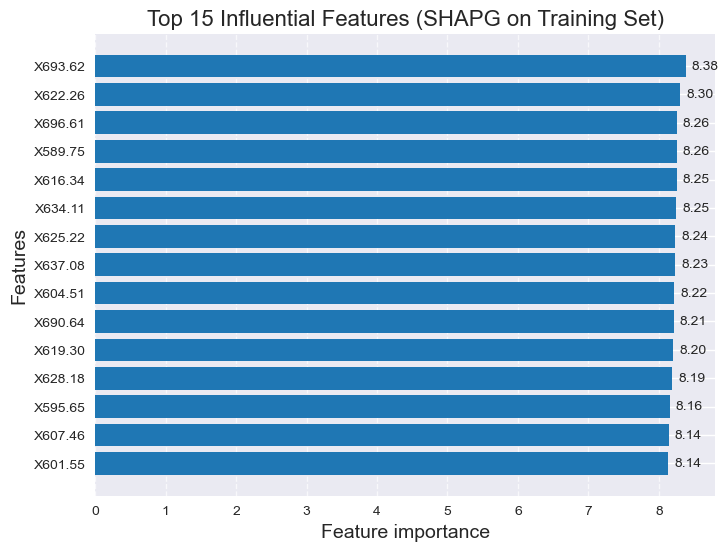

In [30]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# --- NEW: SHAPG Analysis on the Training Set Only ---

# Step 1: Build the similarity matrix (and graph) using only the training data.
# This means we only capture feature relationships as seen on X_train.
W = matrix_generator(X_train_df, kl)
A, W_new = create_minimal_edge_graph(W, reverse=True, version='v3')
G = nx.Graph(A)

# Step 2: Redefine the characteristic function to use only the training set.
# Here we use an internal train/validation split on X_train & y_train 
# to evaluate the performance of each feature subset.

def classification_kpi(G, S):
    """
    Characteristic function for SHAPG XAI on the training set.
    It splits X_train (only the selected columns) into an inner train/validation,
    trains a logistic regression model (using your tuned hyperparameters),
    and returns the evaluation score (F1 score) on the validation set.
    
    Args:
        G (nx.Graph): The feature graph (not directly used in the function).
        S (list): A list of feature names (columns) in X_train.
    
    Returns:
        float: The F1 score for the model trained on the subset S.
    """
    cols = list(S)
    if len(cols) == 0:
        return 0
    else:
        # Internal split on training data only:
        X_train_sub, X_val, y_train_sub, y_val = train_test_split(
            X_train_df[cols], y_train, test_size=0.2, random_state=42
        )
        # Use a fixed logistic regression with your best-tuned parameters:
        model_kpi = LogisticRegression(**best_params_lr, max_iter=5000, tol=1e-3, random_state=random_state)
        model_kpi.fit(X_train_sub, y_train_sub)
        y_pred = model_kpi.predict(X_val)
        # For binary or multi-class classification, choose the appropriate averaging.
        score = f1_score(y_val, y_pred, average='binary')
        return score

# Step 3: Run the SHAPG algorithm using the feature graph G and your new KPI function.
shapley_value = shapley.shapG(G, m=3, f=classification_kpi, approximate_by_ratio=False)

# Step 4: Visualize the SHAPG results.
fig, ax = shapGplot(shapley_value, top_n=15, show_plot=False)
ax.set_xlabel("Feature importance", fontsize=14)
ax.set_ylabel("Features", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Top 15 Influential Features (SHAPG on Training Set)', fontsize=16)
plt.show()


#### <font color=green> Random Forest </font>

C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Cross-Validation Scores from GridSearchCV:
      mean_test_score  std_test_score  \
0           0.788889        0.133333   
1           0.805556        0.143802   
2           0.811111        0.140984   
3           0.805556        0.143802   
4           0.800000        0.152550   
..               ...             ...   
283         0.800000        0.143157   
284         0.822222        0.127415   
285         0.794444        0.147615   
286         0.800000        0.130762   
287         0.788889        0.146566   

                                                params  
0    {'max_depth': None, 'max_features': 'sqrt', 'm...  
1    {'max_depth': None, 'max_features': 'sqrt', 'm...  
2    {'max_depth': None, 'max_features': 'sqrt', 'm...  
3    {'max_depth': None, 'max_features': 'sqrt', 'm...  
4    {'max_depth': None, 'max_features': '

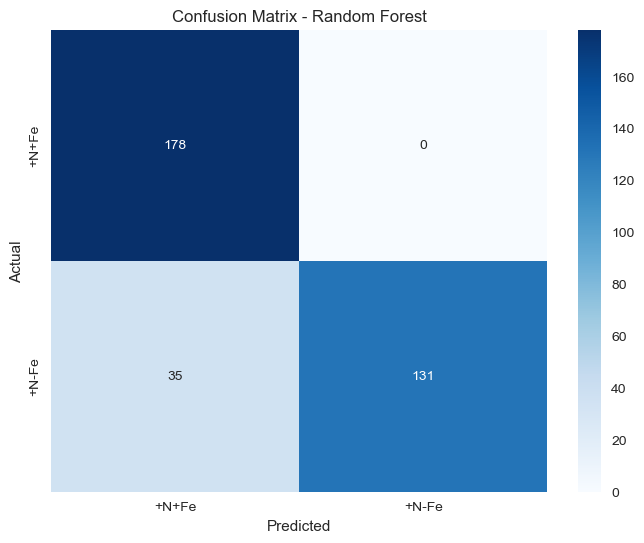

Random Forest shap_values shape is (180, 169, 2)
Selected SHAP values shape: (180, 169)


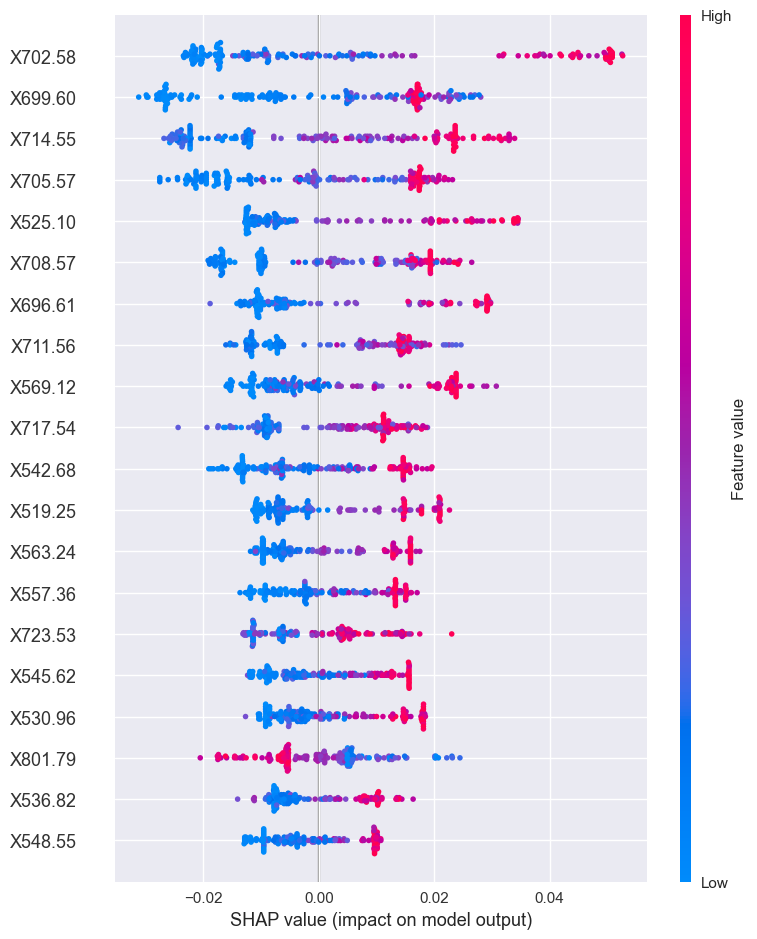

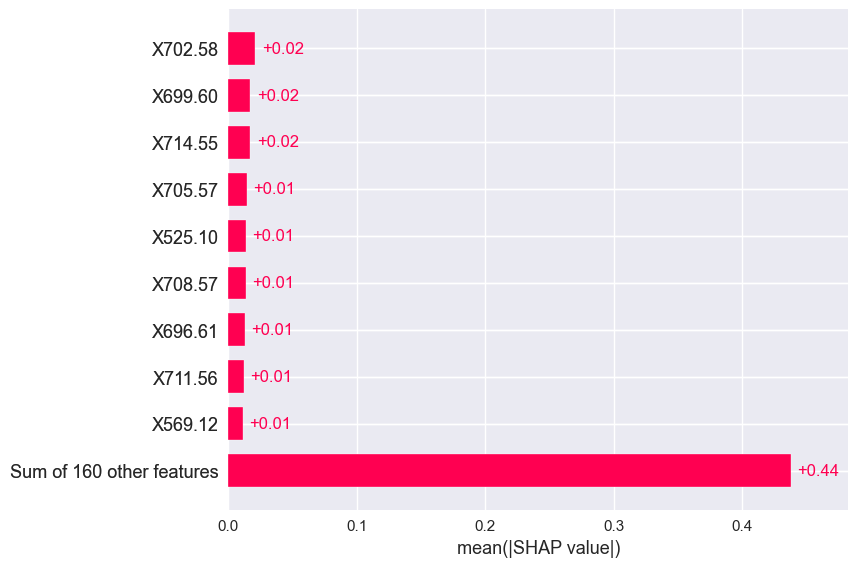

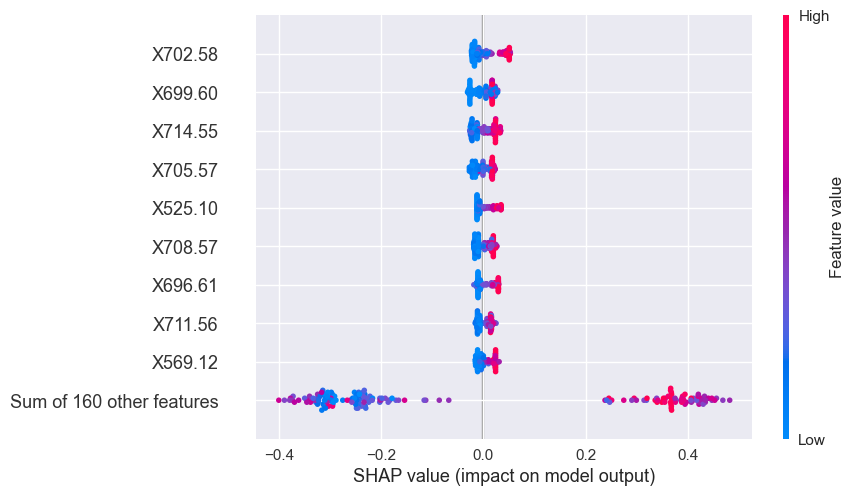

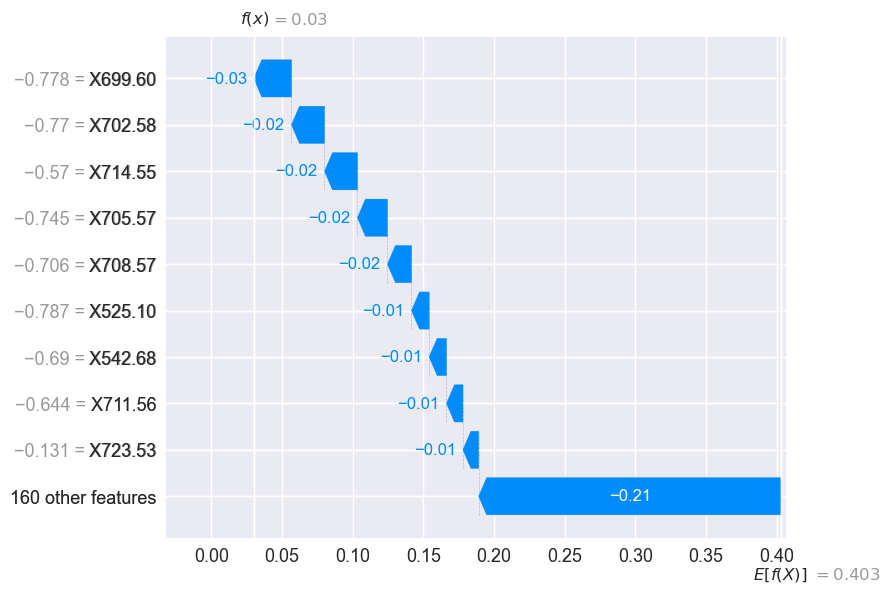

Model classes: [0 1]


In [27]:
### Random Forest Classifier ###
# Hyperparameter Tuning and Cross-Validation for Random Forest
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# Set a random_state for reproducibility
random_state = 42
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_params_rf = grid_search_rf.best_params_
print("Best parameters for Random Forest:", best_params_rf)

# Print Cross-Validation Scores from GridSearchCV
cv_results_rf = pd.DataFrame(grid_search_rf.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_rf[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best Random Forest model
rf_model = RandomForestClassifier(**best_params_rf,random_state=random_state)

# Train the model on the entire training set
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_scaled_te)

# Model Evaluation for Random Forest
print("\nRandom Forest - Test Set Accuracy:", accuracy_score(y_te, y_pred_rf))
print("Test Set Classification Report:")
print(classification_report(y_te, y_pred_rf))

# make sure the labels match
print("Unique values in y_te:", np.unique(y_te))
print("Unique values in y_pred:", np.unique(y_pred))


# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_te, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SHAP Analysis, on train set
# Use TreeExplainer for Random Forest
explainer_rf = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values_rf = explainer_rf.shap_values(X_train)
print("Random Forest shap_values shape is", np.shape(shap_values_rf))

# Select the SHAP values for the positive class (class 1)
shap_values_rf_selected = shap_values_rf[:, :, 1]
# Print the shape of the resulting array
print("Selected SHAP values shape:", shap_values_rf_selected.shape)

# Create an Explanation object
shap_values_rf_explanation = shap.Explanation(
    shap_values_rf_selected,
    base_values=explainer_rf.expected_value[1],  # Use the expected value of the positive class
    data=X_train,
    feature_names=feature_names
    # feature_names=feature_names_reduced
)

# Generate SHAP plots for the Train set
# Summary Plot
shap.summary_plot(shap_values_rf_explanation, X_train, feature_names=feature_names)
# shap.summary_plot(shap_values_rf_explanation, X_train, feature_names=feature_names_reduced)
# Bar Plot
shap.plots.bar(shap_values_rf_explanation)

# Beeswarm Plot
shap.plots.beeswarm(shap_values_rf_explanation)

# Waterfall Plot for the first instance
shap.plots.waterfall(shap_values_rf_explanation[0])

print("Model classes:", rf_model.classes_)

C:\Users\hassa\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


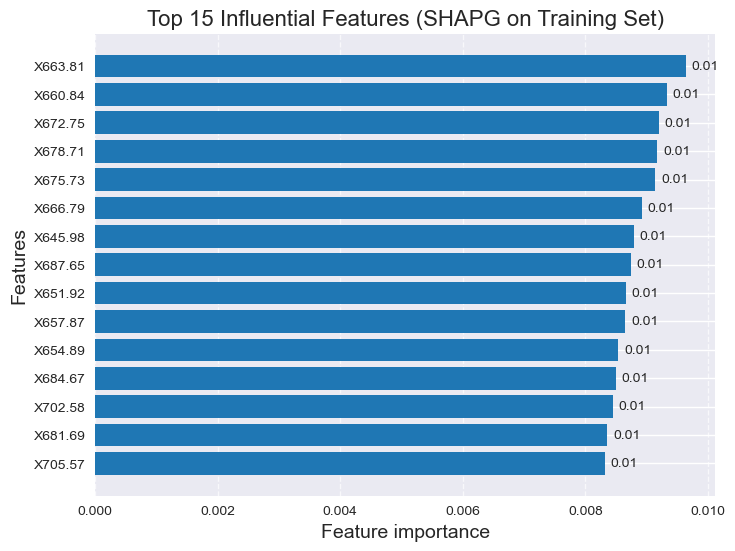

In [31]:


X_train_df = pd.DataFrame(X_train, columns=X.columns)


# --- NEW: SHAPG Analysis on the Training Set Only ---

# Step 1: Build the similarity matrix (and graph) using only the training data.
# This means we only capture feature relationships as seen on X_train.
W = matrix_generator(X_train_df, kl)
A, W_new = create_minimal_edge_graph(W, reverse=True, version='v3')
G = nx.Graph(A)

# Step 2: Redefine the characteristic function to use only the training set.
# Here we use an internal train/validation split on X_train & y_train 
# to evaluate the performance of each feature subset.

def classification_kpi(G, S):
    """
    Characteristic function for SHAPG XAI on the training set.
    It splits X_train (only the selected columns) into an inner train/validation,
    trains a logistic regression model (using your tuned hyperparameters),
    and returns the evaluation score (F1 score) on the validation set.
    
    Args:
        G (nx.Graph): The feature graph (not directly used in the function).
        S (list): A list of feature names (columns) in X_train.
    
    Returns:
        float: The F1 score for the model trained on the subset S.
    """
    cols = list(S)
    if len(cols) == 0:
        return 0
    else:
        # Internal split on training data only:
        X_train_sub, X_val, y_train_sub, y_val = train_test_split(
            X_train_df[cols], y_train, test_size=0.2, random_state=42
        )
        # Use a fixed logistic regression with your best-tuned parameters:
        # Initialize the best Random Forest model
        model_kpi_rf = RandomForestClassifier(**best_params_rf,random_state=random_state)
        model_kpi_rf.fit(X_train_sub, y_train_sub)
        y_pred_rf = model_kpi_rf.predict(X_val)
        # For binary or multi-class classification, choose the appropriate averaging.
        score = f1_score(y_val, y_pred_rf, average='binary')
        return score

# Step 3: Run the SHAPG algorithm using the feature graph G and your new KPI function.
shapley_value_rf = shapley.shapG(G, m=3, f=classification_kpi, approximate_by_ratio=True)

# Step 4: Visualize the SHAPG results.
fig, ax = shapGplot(shapley_value_rf, top_n=15, show_plot=False)
ax.set_xlabel("Feature importance", fontsize=14)
ax.set_ylabel("Features", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Top 15 Influential Features (SHAPG on Training Set)', fontsize=16)
plt.show()


### Under the comission of the PhD student's order

#### Use the following cell as a <font color=red> "stand-alone Logistic Regression" </font> for plan C Prime split
#### run from the ast cell each time, or the sizes will collapse and it will engender error!

In [11]:
# # Function to train and evaluate a model, and compute SHAP values
# def train_evaluate_shap(X_train, y_train, X_test, y_test, feature_names):
#     # Define the parameter grid for Logistic Regression
#     param_grid_lr = {
#         'C': [0.01, 0.1, 1, 10, 30],
#         'penalty': ['l2'],
#         'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']  # Solvers that support multinomial
#     }

#     # Initialize the Logistic Regression model
#     lr_model = LogisticRegression(max_iter=1000, tol=1e-3, random_state=random_state)

#     # Perform GridSearchCV with cross-validation
#     grid_search_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid_lr, cv=5, scoring='accuracy')
#     grid_search_lr.fit(X_train, y_train)
#     best_params_lr = grid_search_lr.best_params_
#     print("Best parameters for Logistic Regression:", best_params_lr)

#     # Train the best model on the entire training set
#     best_lr_model = LogisticRegression(**best_params_lr, max_iter=1000, tol=1e-3, random_state=random_state)
#     best_lr_model.fit(X_train, y_train)

#     # Extract coefficients and intercept
#     coefficients = best_lr_model.coef_[0]  # For binary classification; adjust for multiclass
#     intercept = best_lr_model.intercept_[0]  # For binary classification; adjust for multiclass

#     # Print coefficients and intercept with feature names
#     print("Intercept:", intercept)
#     print("Coefficients:")
#     for feature, coef in zip(feature_names, coefficients):
#         print(f"{feature}: {coef}")

#     # Make predictions on the test set
#     y_pred = best_lr_model.predict(X_test)

#     # Evaluate the model
#     accuracy = accuracy_score(y_test, y_pred)
#     print("\nLogistic Regression - Test Set Accuracy:", accuracy)
#     print("Test Set Classification Report:")
#     print(classification_report(y_test, y_pred))

#     # Confusion Matrix
#     conf_matrix = confusion_matrix(y_test, y_pred)

#     # Calculate SHAP values
#     explainer = shap.Explainer(best_lr_model, X_train)
#     shap_values = explainer(X_test)
#     return accuracy, conf_matrix, y_test, y_pred, shap_values, feature_names, intercept, coefficients


# # Initialize random state
# random_state = 42

# # # Grouping the data by plant using X_scaled and y, when Train_set:original dataset (Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe)
# # plant_groups_scaled = {
# #     "Plant1": (X_scaled[0:36], y[0:36 ),
# #     "Plant2": (X_scaled[36:72], y[36:72]),
# #     "Plant3": (X_scaled[72:108], y[72:108]),
# #     "Plant4": (X_scaled[108:144], y[108:144])
# # }


# # Grouping the data by plant using X_scaled and y, when Train_set:Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe_modified or Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe_add36_randomly
# plant_groups_scaled = {
#     "Plant1": (np.concatenate([X_scaled[0:36], X_scaled[144:153]]), 
#            np.concatenate([y[0:36], y[144:153]])),
#     "Plant2": (np.concatenate([X_scaled[36:72], X_scaled[153:162]]), 
#            np.concatenate([y[36:72], y[153:162]])),
#     "Plant3": (np.concatenate([X_scaled[72:108], X_scaled[162:171]]), 
#            np.concatenate([y[72:108], y[162:171]])),
#     "Plant4": (np.concatenate([X_scaled[108:144], X_scaled[171:180]]), 
#            np.concatenate([y[108:144], y[171:180]]))
# }



# # Shuffle the data for each plant once before starting the for loops
# for plant in plant_groups_scaled.keys():
#     X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
#     plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# # Lists to store accuracies, confusion matrices, predictions, SHAP values, intercepts, and coefficients from each iteration
# accuracies = []
# conf_matrices = []
# all_y_true = []
# all_y_pred = []
# shap_values_list = []
# all_intercepts = []
# all_coefficients = []

# # Number of splits
# n_splits = 4

# # Iterate to split the dataset
# for i in range(n_splits):
#     X_train_list = []
#     y_train_list = []
#     X_test_list = []
#     y_test_list = []

#     # Iterate over each plant species
#     for plant in plant_groups_scaled.keys():
#         X = plant_groups_scaled[plant][0]
#         y = plant_groups_scaled[plant][1]

#         # Define the indices for the current split
#         test_size = len(X) // n_splits
#         test_indices = range(i * test_size, (i + 1) * test_size)
#         train_indices = list(set(range(len(X))) - set(test_indices))

#         # Split the data for the current iteration
#         X_train_plant = X[train_indices]
#         y_train_plant = y[train_indices]
#         X_test_plant = X[test_indices]
#         y_test_plant = y[test_indices]

#         # Append to the respective lists
#         X_train_list.append(X_train_plant)
#         y_train_list.append(y_train_plant)
#         X_test_list.append(X_test_plant)
#         y_test_list.append(y_test_plant)

#     # Concatenate the lists to form the final train and test sets
#     X_train = np.concatenate(X_train_list, axis=0)
#     y_train = np.concatenate(y_train_list, axis=0)
#     X_test = np.concatenate(X_test_list, axis=0)
#     y_test = np.concatenate(y_test_list, axis=0)

#     print(" X_train size", len(X_train))
#     print(" X_train size", len(X_test))
#     # Shuffle the concatenated train and test sets to remove any order-based bias
#     X_train, y_train = shuffle(X_train, y_train, random_state=random_state)

#     # Train and evaluate the model, and get SHAP values
#     accuracy, conf_matrix, y_true, y_pred, shap_values, feature_names, intercept, coefficients = train_evaluate_shap(
#         X_train, y_train, X_test, y_test, feature_names
#     )

#     # Append the current results to the lists
#     accuracies.append(accuracy)
#     conf_matrices.append(conf_matrix)
#     all_y_true.extend(y_true)
#     all_y_pred.extend(y_pred)
#     shap_values_list.append(shap_values)
#     all_intercepts.append(intercept)
#     all_coefficients.append(coefficients)

#     # Plot the confusion matrix for each iteration
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
#     plt.title(f"Confusion Matrix - Iteration {i+1}")
#     plt.xlabel("Predicted")
#     plt.ylabel("Actual")
#     plt.show()

# # Calculate the average accuracy
# average_accuracy = np.mean(accuracies)
# print("\nAverage Accuracy Across 4 Iterations:", average_accuracy)

# # Combine confusion matrices by summing them up
# combined_conf_matrix = np.sum(conf_matrices, axis=0)

# # Calculate the averaged intercept and coefficients
# averaged_intercept = np.mean(all_intercepts)
# averaged_coefficients = np.mean(all_coefficients, axis=0)

# # Save the results of each run and their average to a .txt file
# output_file = "feature_coefficients_all_runs_and_average.txt"
# with open(output_file, "w") as f:
#     # Header
#     f.write("Intercepts and Coefficients for Each Run:\n")
#     f.write("======================================\n\n")

#     # Write the results for each run
#     for i, (intercept, coef_list) in enumerate(zip(all_intercepts, all_coefficients)):
#         f.write(f"Run {i + 1}:\n")
#         f.write(f"Intercept: {intercept}\n")
#         f.write("Coefficients:\n")
#         for feature, coef in zip(feature_names, coef_list):
#             f.write(f"{feature}: {coef}\n")
#         f.write("\n")  # Add a newline between runs

#     # Write the averaged intercept and coefficients
#     f.write("\nAveraged Intercept and Coefficients:\n")
#     f.write("======================================\n")
#     f.write(f"Averaged Intercept: {averaged_intercept}\n")
#     f.write("Averaged Coefficients:\n")
#     for feature, coef in zip(feature_names, averaged_coefficients):
#         f.write(f"{feature}: {coef}\n")

# print(f"All runs' coefficients and averaged results saved to {output_file}")

# # Plot the combined confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(combined_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
# plt.title("Combined Confusion Matrix - Logistic Regression")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # Calculate precision, recall, and F1-score using the aggregated results
# precision = precision_score(all_y_true, all_y_pred, average='micro')
# recall = recall_score(all_y_true, all_y_pred, average='micro')
# f1 = f1_score(all_y_true, all_y_pred, average='micro')

# print(f"\nOverall Precision: {precision}")
# print(f"Overall Recall: {recall}")
# print(f"Overall F1-score: {f1}")




#### Use the following cell as a <font color=red> "stand-alone RandomForest" </font> for plan C Prime split
#### run from the ast cell each time, or the sizes will collapse and it will engender error!

In [10]:
# # Function to train and evaluate a model, and compute SHAP values
# def train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names):
#     # Define the parameter grid for Random Forest
#     param_grid_rf = {
#         'n_estimators': [10, 50, 100, 200],
#         'max_depth': [None, 10, 20, 30],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#         'max_features': ['sqrt', 'log2']
#     }
#     random_state = 42

#     # Perform GridSearchCV with cross-validation
#     grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
#     grid_search_rf.fit(X_train, y_train)
#     best_params_rf = grid_search_rf.best_params_
#     print("Best parameters for Random Forest:", best_params_rf)

#     # Initialize the best Random Forest model
#     best_rf_model = RandomForestClassifier(**best_params_rf, random_state=random_state)
#     best_rf_model.fit(X_train, y_train)

#     # Make predictions on the test set
#     y_pred_rf = best_rf_model.predict(X_test)

#     # Evaluate the model
#     accuracy_rf = accuracy_score(y_test, y_pred_rf)
#     print("\nRandom Forest - Test Set Accuracy:", accuracy_rf)
#     print("Test Set Classification Report:")
#     print(classification_report(y_test, y_pred_rf))

#     # Confusion Matrix
#     conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

#     # Calculate SHAP values using TreeExplainer
#     explainer_rf = shap.TreeExplainer(best_rf_model)
#     shap_values_rf = explainer_rf.shap_values(X_test)
#     print("shap_values_rf's shape", shap_values_rf.shape)
#     return accuracy_rf, conf_matrix_rf, y_test, y_pred_rf, shap_values_rf, explainer_rf, feature_names

# # Initialize random state
# random_state = 42

# # # Grouping the data by plant using X_scaled and y, when Train_set:original dataset (Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe)
# # plant_groups_scaled = {
# #     "Plant1": (X_scaled[0:36], y[0:36]),
# #     "Plant2": (X_scaled[36:72], y[36:72]),
# #     "Plant3": (X_scaled[72:108], y[72:108]),
# #     "Plant4": (X_scaled[108:144], y[108:144])
# # }

# # Grouping the data by plant using X_scaled and y, when Train_set:Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe_modified or Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe_add36_randomly
# plant_groups_scaled = {
#     "Plant1": (np.concatenate([X_scaled[0:36], X_scaled[144:153]]), 
#            np.concatenate([y[0:36], y[144:153]])),
#     "Plant2": (np.concatenate([X_scaled[36:72], X_scaled[153:162]]), 
#            np.concatenate([y[36:72], y[153:162]])),
#     "Plant3": (np.concatenate([X_scaled[72:108], X_scaled[162:171]]), 
#            np.concatenate([y[72:108], y[162:171]])),
#     "Plant4": (np.concatenate([X_scaled[108:144], X_scaled[171:180]]), 
#            np.concatenate([y[108:144], y[171:180]]))
# }

# # 😶😶😶😶😶😶😶😶😶😶😶😶
# # Shuffle the data for each plant once before starting the for loops
# for plant in plant_groups_scaled.keys():
#     X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
#     plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# # Lists to store accuracies, confusion matrices, predictions, and SHAP values from each iteration
# accuracies_rf = []
# conf_matrices_rf = []
# all_y_true_rf = []
# all_y_pred_rf = []
# shap_values_list_rf = []
# explainer_rf_list = []

# # Number of splits
# n_splits = 4

# # Iterate to split the dataset
# for i in range(n_splits):
#     X_train_list = []
#     y_train_list = []
#     X_test_list = []
#     y_test_list = []

#     # Iterate over each plant species
#     for plant in plant_groups_scaled.keys():
#         X = plant_groups_scaled[plant][0]
#         y = plant_groups_scaled[plant][1]
        
#         # Define the indices for the current split
#         test_size = len(X) // n_splits
#         test_indices = range(i * test_size, (i + 1) * test_size)
#         train_indices = list(set(range(len(X))) - set(test_indices))
        
#         # Split the data for the current iteration
#         X_train_plant = X[train_indices]
#         y_train_plant = y[train_indices]
#         X_test_plant = X[test_indices]
#         y_test_plant = y[test_indices]
        
#         # Append to the respective lists
#         X_train_list.append(X_train_plant)
#         y_train_list.append(y_train_plant)
#         X_test_list.append(X_test_plant)
#         y_test_list.append(y_test_plant)

#     # Concatenate the lists to form the final train and test sets
#     X_train = np.concatenate(X_train_list, axis=0)
#     y_train = np.concatenate(y_train_list, axis=0)
#     X_test = np.concatenate(X_test_list, axis=0)
#     y_test = np.concatenate(y_test_list, axis=0)

#     # 😶😶😶😶😶😶😶😶😶😶😶😶
#     # Shuffle the concatenated train and test sets to remove any order-based bias
#     X_train, y_train = shuffle(X_train, y_train, random_state=random_state)

    
#     # Confirm the shape of the train and test sets
#     print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
#     print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

#     # Train and evaluate the model, and get SHAP values
#     accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names)
#     # accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names_reduced)

    
#     accuracies_rf.append(accuracy_rf)
#     conf_matrices_rf.append(conf_matrix_rf)
#     all_y_true_rf.extend(y_true_rf)
#     all_y_pred_rf.extend(y_pred_rf)
#     shap_values_list_rf.append(shap_values_rf)
#     explainer_rf_list.append(explainer_rf)

#     # Plot the confusion matrix for each iteration
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
#     plt.title(f"Confusion Matrix - Iteration {i+1}")
#     plt.xlabel("Predicted")
#     plt.ylabel("Actual")
#     plt.show()

# # Calculate the average accuracy
# average_accuracy_rf = np.mean(accuracies_rf)
# print("\nAverage Accuracy Across 4 Iterations:", average_accuracy_rf)

# # Combine confusion matrices by summing them up
# # Combine confusion matrices by summing them up
# combined_conf_matrix_rf = np.sum(conf_matrices_rf, axis=0)

# # Plot the combined confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(combined_conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
# plt.title("Combined Confusion Matrix - Random Forest")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # Calculate precision, recall, and F1-score using the aggregated results
# precision_rf = precision_score(all_y_true_rf, all_y_pred_rf, average='micro')
# recall_rf = recall_score(all_y_true_rf, all_y_pred_rf, average='micro')
# f1_rf = f1_score(all_y_true_rf, all_y_pred_rf, average='micro')

# print(f"\nOverall Precision: {precision_rf}")
# print(f"Overall Recall: {recall_rf}")
# print(f"Overall F1-score: {f1_rf}")
